# Hill Climbing Algorithm - Hospital Placement Optimization

[Reference: CS50 AI - Lecture 3: Optimization](https://cs50.harvard.edu/ai/2020/weeks/3/)

---

## What is Optimization?

**Optimization** is the process of choosing the **best option from a set of options**.

In AI, we often need to find the best configuration, arrangement, or solution among many possibilities.

---

## What is Local Search?

**Local Search** is a family of search algorithms that:
- Maintain a **single node** (current state)
- Search by **moving to a neighboring node**
- Unlike BFS/DFS, we don't explore the entire search tree

**Key difference from previous search algorithms (BFS, DFS, A*):**
- BFS/DFS/A* find a **path** from start to goal
- Local search finds the **best configuration** (no path needed)

---

## State-Space Landscape

Imagine a landscape where:
- **X-axis** = different possible states
- **Y-axis** = value of the objective/cost function

Key terminology:
- **Objective function**: a function we want to **maximize** (find the **global maximum**)
- **Cost function**: a function we want to **minimize** (find the **global minimum**)
- **Current state**: where we are right now on the landscape
- **Neighbors**: states adjacent to the current state

---

## Hill Climbing Algorithm

**Hill Climbing** is a local search algorithm:

```
function HILL-CLIMB(problem):
    current = initial state of problem
    repeat:
        neighbor = best valued neighbor of current
        if neighbor not better than current:
            return current
        current = neighbor
```

It works like climbing a hill in fog - you can only see your immediate neighbors, and you always move to the best one.

---

## Our Problem: Hospital Placement

**Goal:** Place hospitals on a grid so that the **total distance** from all houses to their **nearest hospital** is **minimized**.

- We have a grid of size `height x width`
- Houses are placed at fixed positions
- We need to place `num_hospitals` hospitals optimally
- **Cost** = sum of Manhattan distances from each house to its nearest hospital
- We want to **minimize** this cost

Let's build this step by step!

---

## Step 1: Setting Up the Grid (State Space)

In [1]:
# Step 1a: Define the grid dimensions
# Our state space is a 2D grid

height = 5   # number of rows
width = 8    # number of columns
num_hospitals = 2  # how many hospitals to place

print(f"Grid size: {height} rows x {width} columns")
print(f"Total cells: {height * width}")
print(f"Hospitals to place: {num_hospitals}")

Grid size: 5 rows x 8 columns
Total cells: 40
Hospitals to place: 2


In [2]:
# Step 1b: Visualize the empty grid
# Each cell is represented by (row, col)

print("Our empty grid (row, col):")
print("=" * 50)
for row in range(height):
    for col in range(width):
        print(f"({row},{col})", end=" ")
    print()  # new line after each row
print("=" * 50)

Our empty grid (row, col):
(0,0) (0,1) (0,2) (0,3) (0,4) (0,5) (0,6) (0,7) 
(1,0) (1,1) (1,2) (1,3) (1,4) (1,5) (1,6) (1,7) 
(2,0) (2,1) (2,2) (2,3) (2,4) (2,5) (2,6) (2,7) 
(3,0) (3,1) (3,2) (3,3) (3,4) (3,5) (3,6) (3,7) 
(4,0) (4,1) (4,2) (4,3) (4,4) (4,5) (4,6) (4,7) 


### Step 1 Summary

| Concept | Value |
|---------|-------|
| Grid Height | 5 rows |
| Grid Width | 8 columns |
| Total Cells | 40 |
| Hospitals to place | 2 |

Each cell is identified by a **(row, col)** tuple. Row 0 is the top, row 4 is the bottom.

---

## Step 2: Placing Houses on the Grid

In [3]:
# Step 2a: Define house positions
# Houses are fixed - they don't move
# We use a set for fast lookup

houses = set()

# Add houses at specific locations
houses.add((0, 1))  # House at row=0, col=1
houses.add((1, 5))  # House at row=1, col=5
houses.add((3, 2))  # House at row=3, col=2
houses.add((4, 7))  # House at row=4, col=7

print("Houses are located at:")
for h in sorted(houses):
    print(f"  House at row={h[0]}, col={h[1]}")
print(f"\nTotal houses: {len(houses)}")

Houses are located at:
  House at row=0, col=1
  House at row=1, col=5
  House at row=3, col=2
  House at row=4, col=7

Total houses: 4


In [4]:
# Step 2b: Visualize the grid with houses

def print_grid(height, width, houses, hospitals=set()):
    """Display the grid with houses and hospitals."""
    print("\n" + "=" * (width * 4 + 1))
    for row in range(height):
        print("|", end="")
        for col in range(width):
            if (row, col) in houses:
                print(" H ", end="|")
            elif (row, col) in hospitals:
                print(" + ", end="|")
            else:
                print("   ", end="|")
        print()
        print("-" * (width * 4 + 1))
    print("\nLegend: H = House, + = Hospital")

print("Grid with houses:")
print_grid(height, width, houses)

Grid with houses:

|   | H |   |   |   |   |   |   |
---------------------------------
|   |   |   |   |   | H |   |   |
---------------------------------
|   |   |   |   |   |   |   |   |
---------------------------------
|   |   | H |   |   |   |   |   |
---------------------------------
|   |   |   |   |   |   |   | H |
---------------------------------

Legend: H = House, + = Hospital


### Step 2 Summary

We have 4 houses placed on our 5x8 grid. These houses are **fixed** - they will not move. Our job is to find the **best positions** for 2 hospitals so that houses are as close as possible to their nearest hospital.

---

## Step 3: Understanding Manhattan Distance (The Cost)

In [5]:
# Step 3a: Manhattan Distance between two points
# Manhattan distance = |row1 - row2| + |col1 - col2|
# This is the "city block" distance (no diagonal movement)

def manhattan_distance(point1, point2):
    """Calculate Manhattan distance between two (row, col) points."""
    return abs(point1[0] - point2[0]) + abs(point1[1] - point2[1])

# Example: distance from house at (0,1) to a hospital at (2,3)
house = (0, 1)
hospital = (2, 3)

dist = manhattan_distance(house, hospital)
print(f"House at {house} to Hospital at {hospital}:")
print(f"  |{house[0]} - {hospital[0]}| + |{house[1]} - {hospital[1]}|")
print(f"  = |{house[0] - hospital[0]}| + |{house[1] - hospital[1]}|")
print(f"  = {abs(house[0] - hospital[0])} + {abs(house[1] - hospital[1])}")
print(f"  = {dist}")

House at (0, 1) to Hospital at (2, 3):
  |0 - 2| + |1 - 3|
  = |-2| + |-2|
  = 2 + 2
  = 4


In [6]:
# Step 3b: Cost Function - sum of distances from each house to nearest hospital

def get_cost(houses, hospitals):
    """
    Calculates the total cost:
    For each house, find the distance to the NEAREST hospital,
    then sum all those distances.
    """
    cost = 0
    for house in houses:
        # Find minimum distance from this house to any hospital
        min_dist = min(
            manhattan_distance(house, hospital)
            for hospital in hospitals
        )
        cost += min_dist
    return cost

# Example: let's try hospitals at (1,1) and (3,6)
test_hospitals = {(1, 1), (3, 6)}

print("Houses:", sorted(houses))
print("Test hospitals:", sorted(test_hospitals))
print("\nDistance from each house to nearest hospital:")

total = 0
for house in sorted(houses):
    distances = []
    for hosp in sorted(test_hospitals):
        d = manhattan_distance(house, hosp)
        distances.append((hosp, d))
    nearest = min(distances, key=lambda x: x[1])
    print(f"  House {house} -> nearest hospital {nearest[0]}, distance = {nearest[1]}")
    total += nearest[1]

print(f"\nTotal cost = {total}")
print(f"Verify with function: {get_cost(houses, test_hospitals)}")

Houses: [(0, 1), (1, 5), (3, 2), (4, 7)]
Test hospitals: [(1, 1), (3, 6)]

Distance from each house to nearest hospital:
  House (0, 1) -> nearest hospital (1, 1), distance = 1
  House (1, 5) -> nearest hospital (3, 6), distance = 3
  House (3, 2) -> nearest hospital (1, 1), distance = 3
  House (4, 7) -> nearest hospital (3, 6), distance = 2

Total cost = 9
Verify with function: 9


### Step 3 Summary

| Concept | Description |
|---------|-------------|
| Manhattan Distance | \|row1 - row2\| + \|col1 - col2\| |
| Cost Function | Sum of distances from each house to its **nearest** hospital |
| Goal | **Minimize** the cost function |

The cost function is what Hill Climbing will try to minimize. Lower cost = better hospital placement.

---

## Step 4: Neighbors - How Hospitals Can Move

In [7]:
# Step 4a: Understanding neighbors
# A hospital can move to any of its 4 adjacent cells (up, down, left, right)
# But NOT to a cell that already has a house or another hospital
# And NOT outside the grid boundaries

def get_neighbors(row, col, height, width, houses, hospitals):
    """
    Returns valid neighboring positions for a hospital at (row, col).
    A neighbor is valid if:
      1. It's within the grid boundaries
      2. It doesn't contain a house
      3. It doesn't contain another hospital
    """
    candidates = [
        (row - 1, col),   # UP
        (row + 1, col),   # DOWN
        (row, col - 1),   # LEFT
        (row, col + 1)    # RIGHT
    ]
    
    neighbors = []
    for r, c in candidates:
        # Skip if out of bounds
        if r < 0 or r >= height or c < 0 or c >= width:
            continue
        # Skip if there's a house or hospital there
        if (r, c) in houses or (r, c) in hospitals:
            continue
        neighbors.append((r, c))
    
    return neighbors

# Example: neighbors of hospital at (1, 1)
test_pos = (1, 1)
test_hospitals = {(1, 1), (3, 6)}

print(f"Hospital at {test_pos}")
print(f"Houses: {sorted(houses)}")
print(f"\nCandidate moves:")
print(f"  UP:    ({test_pos[0]-1}, {test_pos[1]}) -> {'BLOCKED (has house)' if (test_pos[0]-1, test_pos[1]) in houses else 'Valid'}")
print(f"  DOWN:  ({test_pos[0]+1}, {test_pos[1]}) -> {'BLOCKED' if (test_pos[0]+1, test_pos[1]) in houses else 'Valid'}")
print(f"  LEFT:  ({test_pos[0]}, {test_pos[1]-1}) -> {'BLOCKED' if (test_pos[0], test_pos[1]-1) in houses else 'Valid'}")
print(f"  RIGHT: ({test_pos[0]}, {test_pos[1]+1}) -> {'BLOCKED' if (test_pos[0], test_pos[1]+1) in houses else 'Valid'}")

valid_neighbors = get_neighbors(*test_pos, height, width, houses, test_hospitals)
print(f"\nValid neighbors: {valid_neighbors}")

Hospital at (1, 1)
Houses: [(0, 1), (1, 5), (3, 2), (4, 7)]

Candidate moves:
  UP:    (0, 1) -> BLOCKED (has house)
  DOWN:  (2, 1) -> Valid
  LEFT:  (1, 0) -> Valid
  RIGHT: (1, 2) -> Valid

Valid neighbors: [(2, 1), (1, 0), (1, 2)]


In [8]:
# Step 4b: Generating neighboring STATES
# A "state" is the set of ALL hospital positions.
# A "neighboring state" is created by moving ONE hospital to ONE of its neighbors.

hospitals = {(1, 1), (3, 6)}
print(f"Current state (hospitals): {sorted(hospitals)}")
print(f"Current cost: {get_cost(houses, hospitals)}")
print(f"\nAll possible neighboring states:")
print("=" * 60)

all_neighbors = []
for hospital in sorted(hospitals):
    for replacement in get_neighbors(*hospital, height, width, houses, hospitals):
        # Create a new state: remove old position, add new position
        neighbor_state = hospitals.copy()
        neighbor_state.remove(hospital)
        neighbor_state.add(replacement)
        
        cost = get_cost(houses, neighbor_state)
        all_neighbors.append((neighbor_state, cost))
        
        print(f"  Move {hospital} -> {replacement}: "
              f"new state = {sorted(neighbor_state)}, cost = {cost}")

# Find the best neighbor
best = min(all_neighbors, key=lambda x: x[1])
print(f"\nBest neighbor: {sorted(best[0])}, cost = {best[1]}")
print(f"Current cost:  {get_cost(houses, hospitals)}")
print(f"Improvement:   {get_cost(houses, hospitals) - best[1]}")

Current state (hospitals): [(1, 1), (3, 6)]
Current cost: 9

All possible neighboring states:
  Move (1, 1) -> (2, 1): new state = [(2, 1), (3, 6)], cost = 9
  Move (1, 1) -> (1, 0): new state = [(1, 0), (3, 6)], cost = 11
  Move (1, 1) -> (1, 2): new state = [(1, 2), (3, 6)], cost = 9
  Move (3, 6) -> (2, 6): new state = [(1, 1), (2, 6)], cost = 9
  Move (3, 6) -> (4, 6): new state = [(1, 1), (4, 6)], cost = 9
  Move (3, 6) -> (3, 5): new state = [(1, 1), (3, 5)], cost = 9
  Move (3, 6) -> (3, 7): new state = [(1, 1), (3, 7)], cost = 9

Best neighbor: [(2, 1), (3, 6)], cost = 9
Current cost:  9
Improvement:   0


### Step 4 Summary

| Concept | Description |
|---------|-------------|
| Neighbor of a cell | Up, Down, Left, Right (if valid) |
| Neighboring state | Move **one** hospital by **one** cell |
| Invalid neighbors | Out of bounds, occupied by house/hospital |

At each step, Hill Climbing generates ALL neighboring states, evaluates their cost, and picks the **best** one.

---

## Step 5: Available Spaces (for Random Initialization)

In [9]:
# Step 5: Finding available spaces
# Before hill climbing starts, we need to randomly place hospitals.
# Available spaces = all cells - houses - existing hospitals

import random
random.seed(42)  # For reproducibility

def available_spaces(height, width, houses, hospitals):
    """Returns all cells not currently used by a house or hospital."""
    # Generate all possible cells
    candidates = set(
        (row, col)
        for row in range(height)
        for col in range(width)
    )
    # Remove houses and hospitals
    for house in houses:
        candidates.remove(house)
    for hospital in hospitals:
        candidates.remove(hospital)
    return candidates

# Show available spaces
hospitals = set()  # No hospitals yet
spaces = available_spaces(height, width, houses, hospitals)
print(f"Total cells: {height * width}")
print(f"Houses: {len(houses)}")
print(f"Available spaces: {len(spaces)}")

# Randomly place hospitals
hospitals = set()
for i in range(num_hospitals):
    space = random.choice(list(available_spaces(height, width, houses, hospitals)))
    hospitals.add(space)
    print(f"\nHospital {i+1} randomly placed at: {space}")

print(f"\nInitial random placement: {sorted(hospitals)}")
print(f"Initial cost: {get_cost(houses, hospitals)}")

print_grid(height, width, houses, hospitals)

Total cells: 40
Houses: 4
Available spaces: 36

Hospital 1 randomly placed at: (0, 5)

Hospital 2 randomly placed at: (3, 4)

Initial random placement: [(0, 5), (3, 4)]
Initial cost: 11

|   | H |   |   |   | + |   |   |
---------------------------------
|   |   |   |   |   | H |   |   |
---------------------------------
|   |   |   |   |   |   |   |   |
---------------------------------
|   |   | H |   | + |   |   |   |
---------------------------------
|   |   |   |   |   |   |   | H |
---------------------------------

Legend: H = House, + = Hospital


### Step 5 Summary

Hill Climbing starts with a **random initial state**. We randomly place hospitals on available (empty) cells. This random placement is usually not optimal - the algorithm will improve it.

---

## Step 6: The Hill Climbing Algorithm (Complete Implementation)

In [10]:
# Step 6a: Hill Climbing - the complete algorithm

def hill_climb(height, width, houses, num_hospitals, maximum=None, log=True):
    """
    Performs Hill Climbing to find optimal hospital placement.
    
    Algorithm:
    1. Start with random hospital placement
    2. Look at ALL neighboring states (move one hospital by one cell)
    3. If best neighbor is better than current -> move there
    4. If no neighbor is better -> STOP (local minimum found)
    
    Parameters:
        height, width: grid dimensions
        houses: set of house positions
        num_hospitals: number of hospitals to place
        maximum: max iterations (None = unlimited)
        log: print progress
    
    Returns:
        set of hospital positions
    """
    count = 0
    
    # === STEP 1: Random initialization ===
    hospitals = set()
    for i in range(num_hospitals):
        hospitals.add(random.choice(
            list(available_spaces(height, width, houses, hospitals))
        ))
    
    if log:
        print(f"Initial state: {sorted(hospitals)}, cost = {get_cost(houses, hospitals)}")
    
    # === STEP 2: Iteratively improve ===
    while maximum is None or count < maximum:
        count += 1
        best_neighbors = []       # List of best neighbor states (may be ties)
        best_neighbor_cost = None  # Cost of the best neighbor
        
        # Consider moving each hospital
        for hospital in hospitals:
            # Consider each valid neighbor for this hospital
            for replacement in get_neighbors(*hospital, height, width, houses, hospitals):
                # Create the neighboring state
                neighbor = hospitals.copy()
                neighbor.remove(hospital)
                neighbor.add(replacement)
                
                # Evaluate this neighbor
                cost = get_cost(houses, neighbor)
                
                if best_neighbor_cost is None or cost < best_neighbor_cost:
                    # Found a new best!
                    best_neighbor_cost = cost
                    best_neighbors = [neighbor]
                elif cost == best_neighbor_cost:
                    # Tied with current best
                    best_neighbors.append(neighbor)
        
        # === STEP 3: Decide whether to move ===
        current_cost = get_cost(houses, hospitals)
        
        # If no neighbor is better, we're at a local minimum -> STOP
        if best_neighbor_cost >= current_cost:
            if log:
                print(f"\nNo better neighbor found. Stopping at local minimum.")
                print(f"Final state: {sorted(hospitals)}, cost = {current_cost}")
                print(f"Total iterations: {count - 1}")
            return hospitals
        
        # Move to the best neighbor (break ties randomly)
        hospitals = random.choice(best_neighbors)
        
        if log:
            print(f"  Iteration {count}: moved to {sorted(hospitals)}, cost = {best_neighbor_cost}")
    
    return hospitals

In [11]:
# Step 6b: Run Hill Climbing!

random.seed(10)  # For reproducibility

print("Houses:", sorted(houses))
print(f"Grid: {height}x{width}, Hospitals: {num_hospitals}")
print("\n" + "=" * 60)
print("RUNNING HILL CLIMBING")
print("=" * 60 + "\n")

result = hill_climb(height, width, houses, num_hospitals, log=True)

print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)
print_grid(height, width, houses, result)

Houses: [(0, 1), (1, 5), (3, 2), (4, 7)]
Grid: 5x8, Hospitals: 2

RUNNING HILL CLIMBING

Initial state: [(1, 1), (4, 3)], cost = 11

No better neighbor found. Stopping at local minimum.
Final state: [(1, 1), (4, 3)], cost = 11
Total iterations: 0

FINAL RESULT

|   | H |   |   |   |   |   |   |
---------------------------------
|   | + |   |   |   | H |   |   |
---------------------------------
|   |   |   |   |   |   |   |   |
---------------------------------
|   |   | H |   |   |   |   |   |
---------------------------------
|   |   |   | + |   |   |   | H |
---------------------------------

Legend: H = House, + = Hospital


### Step 6: How Hill Climbing Works - Visualized

```
Iteration 0 (Start):    Place hospitals RANDOMLY
                         Cost = high (probably bad)
                              |
                              v
Iteration 1:             Look at ALL neighbors
                         Pick the BEST one
                         Cost decreases!
                              |
                              v
Iteration 2:             Look at ALL neighbors again
                         Pick the BEST one
                         Cost decreases more!
                              |
                              v
     ...                      |
                              v
Iteration N:             NO neighbor is better
                         -> STOP! Local minimum reached.
```

**Key insight:** Hill Climbing is **greedy** - it always moves to the best neighbor. This means it can get **stuck at local minima** (a state that is better than all neighbors, but not the global best).

---

## Step 7: The Problem with Hill Climbing - Local Minima

In [12]:
# Step 7a: Run hill climbing multiple times to see different results
# Since it starts randomly, different runs may find different local minima

print("Running Hill Climbing 5 times with different random seeds:")
print("=" * 60)

results = []
for seed in range(5):
    random.seed(seed)
    result = hill_climb(height, width, houses, num_hospitals, log=False)
    cost = get_cost(houses, result)
    results.append((seed, sorted(result), cost))
    print(f"  Seed {seed}: hospitals = {sorted(result)}, cost = {cost}")

best_run = min(results, key=lambda x: x[2])
worst_run = max(results, key=lambda x: x[2])

print(f"\nBest result:  seed {best_run[0]}, cost = {best_run[2]}")
print(f"Worst result: seed {worst_run[0]}, cost = {worst_run[2]}")
print(f"\nNotice: Different starting points can lead to different local minima!")

Running Hill Climbing 5 times with different random seeds:
  Seed 0: hospitals = [(0, 0), (3, 5)], cost = 9
  Seed 1: hospitals = [(1, 2), (3, 7)], cost = 8
  Seed 2: hospitals = [(0, 2), (3, 1)], cost = 13
  Seed 3: hospitals = [(1, 6), (4, 5)], cost = 13
  Seed 4: hospitals = [(1, 2), (4, 6)], cost = 8

Best result:  seed 1, cost = 8
Worst result: seed 2, cost = 13

Notice: Different starting points can lead to different local minima!


### Local Minima Problem

Hill Climbing can get **stuck** because:

```
Cost
  ^                                  
  |  *                               
  | * *         *                     
  |*   *       * *                    
  |     *     *   *                   
  |      *   *     *                  
  |       * *       * *               
  |        X         * * *            
  |     Local          X              
  |     Minimum     GLOBAL            
  |                 MINIMUM           
  +-------------------------------->
                           States
```

The algorithm stops at a **local minimum** because all neighbors have higher cost, even though the **global minimum** exists elsewhere.

**Solution:** Random Restart Hill Climbing!

---

## Step 8: Random Restart Hill Climbing

In [13]:
# Step 8a: Random Restart - run hill climbing many times, keep the best

def random_restart(height, width, houses, num_hospitals, maximum=20, log=True):
    """
    Repeats hill climbing multiple times and keeps the best result.
    
    This overcomes the local minima problem by trying many
    different random starting points.
    
    Parameters:
        maximum: number of times to restart hill climbing
    """
    best_hospitals = None
    best_cost = None
    
    for i in range(maximum):
        # Run one round of hill climbing
        hospitals = hill_climb(height, width, houses, num_hospitals, log=False)
        cost = get_cost(houses, hospitals)
        
        # Keep track of the best result
        if best_cost is None or cost < best_cost:
            best_cost = cost
            best_hospitals = hospitals
            if log:
                print(f"  Restart {i+1}: NEW BEST! cost = {cost}, hospitals = {sorted(hospitals)}")
        else:
            if log:
                print(f"  Restart {i+1}: cost = {cost} (best remains {best_cost})")
    
    return best_hospitals

print("RANDOM RESTART HILL CLIMBING")
print("=" * 60)
random.seed(0)

best = random_restart(height, width, houses, num_hospitals, maximum=20)

print(f"\nFinal best cost: {get_cost(houses, best)}")
print(f"Final best hospitals: {sorted(best)}")
print_grid(height, width, houses, best)

RANDOM RESTART HILL CLIMBING
  Restart 1: NEW BEST! cost = 9, hospitals = [(0, 0), (3, 5)]
  Restart 2: cost = 9 (best remains 9)
  Restart 3: cost = 9 (best remains 9)
  Restart 4: cost = 9 (best remains 9)
  Restart 5: NEW BEST! cost = 8, hospitals = [(1, 2), (3, 7)]
  Restart 6: cost = 13 (best remains 8)
  Restart 7: cost = 11 (best remains 8)
  Restart 8: cost = 9 (best remains 8)
  Restart 9: cost = 11 (best remains 8)
  Restart 10: cost = 9 (best remains 8)
  Restart 11: cost = 9 (best remains 8)
  Restart 12: cost = 11 (best remains 8)
  Restart 13: cost = 9 (best remains 8)
  Restart 14: cost = 8 (best remains 8)
  Restart 15: cost = 9 (best remains 8)
  Restart 16: cost = 8 (best remains 8)
  Restart 17: cost = 8 (best remains 8)
  Restart 18: cost = 11 (best remains 8)
  Restart 19: cost = 11 (best remains 8)
  Restart 20: cost = 9 (best remains 8)

Final best cost: 8
Final best hospitals: [(1, 2), (3, 7)]

|   | H |   |   |   |   |   |   |
---------------------------------


### Step 8 Summary

| Approach | Description | Limitation |
|----------|-------------|------------|
| Hill Climbing | Start random, move to best neighbor | Gets stuck at local minima |
| Random Restart | Run hill climbing N times, keep best | More restarts = better chance of finding global minimum |

Random Restart is simple but effective: by trying many different starting points, we are more likely to find the **global minimum**.

---

## Step 9: Putting It All Together - The Space Class

Now let's combine everything into a clean `Space` class (matching the original `hospitals.py`).

In [14]:
# Step 9: The complete Space class

import random

class Space():
    
    def __init__(self, height, width, num_hospitals):
        """Create a new state space with given dimensions."""
        self.height = height
        self.width = width
        self.num_hospitals = num_hospitals
        self.houses = set()
        self.hospitals = set()
    
    def add_house(self, row, col):
        """Add a house at a particular location in state space."""
        self.houses.add((row, col))
    
    def available_spaces(self):
        """Returns all cells not currently used by a house or hospital."""
        candidates = set(
            (row, col)
            for row in range(self.height)
            for col in range(self.width)
        )
        for house in self.houses:
            candidates.remove(house)
        for hospital in self.hospitals:
            candidates.remove(hospital)
        return candidates
    
    def get_cost(self, hospitals):
        """Calculates sum of distances from houses to nearest hospital."""
        cost = 0
        for house in self.houses:
            cost += min(
                abs(house[0] - hospital[0]) + abs(house[1] - hospital[1])
                for hospital in hospitals
            )
        return cost
    
    def get_neighbors(self, row, col):
        """Returns neighbors not already containing a house or hospital."""
        candidates = [
            (row - 1, col),
            (row + 1, col),
            (row, col - 1),
            (row, col + 1)
        ]
        neighbors = []
        for r, c in candidates:
            if (r, c) in self.houses or (r, c) in self.hospitals:
                continue
            if 0 <= r < self.height and 0 <= c < self.width:
                neighbors.append((r, c))
        return neighbors
    
    def hill_climb(self, maximum=None, log=False):
        """Performs hill-climbing to find a solution."""
        count = 0
        
        # Start by initializing hospitals randomly
        self.hospitals = set()
        for i in range(self.num_hospitals):
            self.hospitals.add(random.choice(list(self.available_spaces())))
        if log:
            print(f"Initial state: cost {self.get_cost(self.hospitals)}")
        
        # Continue until we reach maximum number of iterations
        while maximum is None or count < maximum:
            count += 1
            best_neighbors = []
            best_neighbor_cost = None
            
            # Consider all hospitals to move
            for hospital in self.hospitals:
                # Consider all neighbors for that hospital
                for replacement in self.get_neighbors(*hospital):
                    # Generate a neighboring set of hospitals
                    neighbor = self.hospitals.copy()
                    neighbor.remove(hospital)
                    neighbor.add(replacement)
                    
                    # Check if neighbor is best so far
                    cost = self.get_cost(neighbor)
                    if best_neighbor_cost is None or cost < best_neighbor_cost:
                        best_neighbor_cost = cost
                        best_neighbors = [neighbor]
                    elif best_neighbor_cost == cost:
                        best_neighbors.append(neighbor)
            
            # None of the neighbors are better than the current state
            if best_neighbor_cost >= self.get_cost(self.hospitals):
                return self.hospitals
            
            # Move to a highest-valued neighbor
            else:
                if log:
                    print(f"Found better neighbor: cost {best_neighbor_cost}")
                self.hospitals = random.choice(best_neighbors)
    
    def random_restart(self, maximum, log=False):
        """Repeats hill-climbing multiple times."""
        best_hospitals = None
        best_cost = None
        
        for i in range(maximum):
            hospitals = self.hill_climb()
            cost = self.get_cost(hospitals)
            if best_cost is None or cost < best_cost:
                best_cost = cost
                best_hospitals = hospitals
                if log:
                    print(f"{i}: Found new best state: cost {cost}")
            else:
                if log:
                    print(f"{i}: Found state: cost {cost}")
        
        return best_hospitals

print("Space class defined successfully!")

Space class defined successfully!


---

## Step 10: Run the Full Example

In [15]:
# Step 10a: Create a space and add houses (matching original hospitals.py)

random.seed(42)

s = Space(height=10, width=20, num_hospitals=3)

# Add 15 random houses
for i in range(15):
    s.add_house(random.randrange(s.height), random.randrange(s.width))

print(f"Grid: {s.height} x {s.width}")
print(f"Houses ({len(s.houses)}): {sorted(s.houses)}")
print(f"Hospitals to place: {s.num_hospitals}")

Grid: 10 x 20
Houses (15): [(0, 2), (0, 17), (1, 0), (1, 17), (1, 18), (2, 13), (3, 4), (3, 7), (3, 17), (4, 0), (4, 7), (6, 1), (6, 7), (7, 18), (8, 19)]
Hospitals to place: 3


In [16]:
# Step 10b: Run Hill Climbing with logging

print("HILL CLIMBING (single run)")
print("=" * 50)
hospitals = s.hill_climb(log=True)
print(f"\nFinal hospitals: {sorted(hospitals)}")
print(f"Final cost: {s.get_cost(hospitals)}")

HILL CLIMBING (single run)
Initial state: cost 73
Found better neighbor: cost 69
Found better neighbor: cost 67
Found better neighbor: cost 65
Found better neighbor: cost 63
Found better neighbor: cost 62
Found better neighbor: cost 61
Found better neighbor: cost 60
Found better neighbor: cost 59
Found better neighbor: cost 58

Final hospitals: [(3, 5), (3, 13), (3, 18)]
Final cost: 58


In [17]:
# Step 10c: Run Random Restart Hill Climbing

print("RANDOM RESTART HILL CLIMBING (100 restarts)")
print("=" * 50)
best_hospitals = s.random_restart(maximum=100, log=True)
print(f"\nBest hospitals: {sorted(best_hospitals)}")
print(f"Best cost: {s.get_cost(best_hospitals)}")

RANDOM RESTART HILL CLIMBING (100 restarts)
0: Found new best state: cost 47
1: Found state: cost 65
2: Found state: cost 47
3: Found state: cost 58
4: Found state: cost 47
5: Found state: cost 61
6: Found new best state: cost 43
7: Found state: cost 51
8: Found state: cost 47
9: Found state: cost 47
10: Found state: cost 47
11: Found state: cost 73
12: Found state: cost 65
13: Found state: cost 56
14: Found state: cost 56
15: Found state: cost 51
16: Found state: cost 49
17: Found state: cost 49
18: Found state: cost 47
19: Found state: cost 53
20: Found state: cost 56
21: Found state: cost 63
22: Found state: cost 58
23: Found state: cost 43
24: Found state: cost 63
25: Found state: cost 49
26: Found state: cost 51
27: Found state: cost 47
28: Found state: cost 49
29: Found state: cost 51
30: Found state: cost 49
31: Found state: cost 51
32: Found state: cost 47
33: Found state: cost 70
34: Found state: cost 51
35: Found state: cost 58
36: Found state: cost 51
37: Found state: cost 5

---

## Step 11: Visualize the Grid Result with Matplotlib

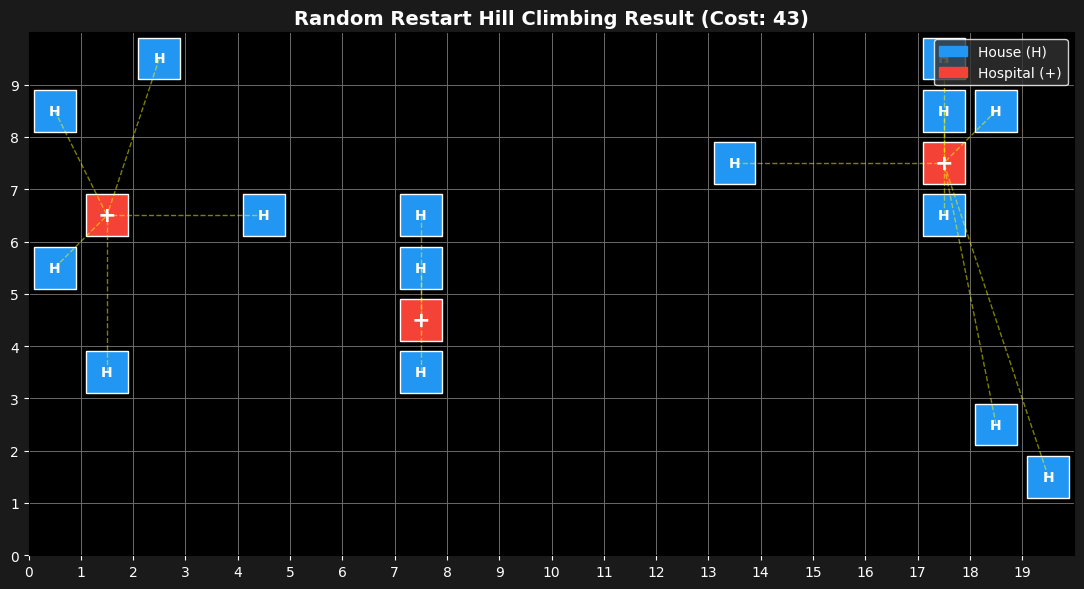

In [18]:
# Step 11: Visualize the final result using matplotlib

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def visualize_grid(space, hospitals, title="Hospital Placement"):
    """Visualize the grid with houses and hospitals using matplotlib."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Draw grid
    for row in range(space.height):
        for col in range(space.width):
            rect = plt.Rectangle((col, space.height - 1 - row), 1, 1,
                                  linewidth=0.5, edgecolor='gray', facecolor='black')
            ax.add_patch(rect)
    
    # Draw houses
    for (row, col) in space.houses:
        rect = plt.Rectangle((col + 0.1, space.height - 1 - row + 0.1), 0.8, 0.8,
                              linewidth=1, edgecolor='white', facecolor='#2196F3')
        ax.add_patch(rect)
        ax.text(col + 0.5, space.height - 1 - row + 0.5, 'H',
                ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    
    # Draw hospitals
    for (row, col) in hospitals:
        rect = plt.Rectangle((col + 0.1, space.height - 1 - row + 0.1), 0.8, 0.8,
                              linewidth=1, edgecolor='white', facecolor='#F44336')
        ax.add_patch(rect)
        ax.text(col + 0.5, space.height - 1 - row + 0.5, '+',
                ha='center', va='center', color='white', fontsize=16, fontweight='bold')
    
    # Draw lines from each house to its nearest hospital
    for house in space.houses:
        nearest = min(hospitals,
                      key=lambda h: abs(house[0]-h[0]) + abs(house[1]-h[1]))
        ax.plot([house[1]+0.5, nearest[1]+0.5],
                [space.height-1-house[0]+0.5, space.height-1-nearest[0]+0.5],
                'yellow', linewidth=1, alpha=0.5, linestyle='--')
    
    cost = space.get_cost(hospitals)
    ax.set_xlim(0, space.width)
    ax.set_ylim(0, space.height)
    ax.set_aspect('equal')
    ax.set_title(f"{title} (Cost: {cost})", fontsize=14, fontweight='bold', color='white')
    ax.set_facecolor('black')
    fig.patch.set_facecolor('#1a1a1a')
    
    # Legend
    house_patch = mpatches.Patch(color='#2196F3', label='House (H)')
    hosp_patch = mpatches.Patch(color='#F44336', label='Hospital (+)')
    ax.legend(handles=[house_patch, hosp_patch], loc='upper right',
              facecolor='#333333', edgecolor='white', labelcolor='white')
    
    ax.set_xticks(range(space.width))
    ax.set_yticks(range(space.height))
    ax.tick_params(colors='white')
    
    plt.tight_layout()
    plt.show()

# Visualize the result
visualize_grid(s, best_hospitals, "Random Restart Hill Climbing Result")

---

## Step 12: Compare Single Hill Climb vs Random Restart

COMPARISON: Single Hill Climb vs Random Restart
Metric                       Single HC  Random Restart
-------------------------------------------------------
Average cost                      53.7            43.5
Best cost                           43              43
Worst cost                          73              47


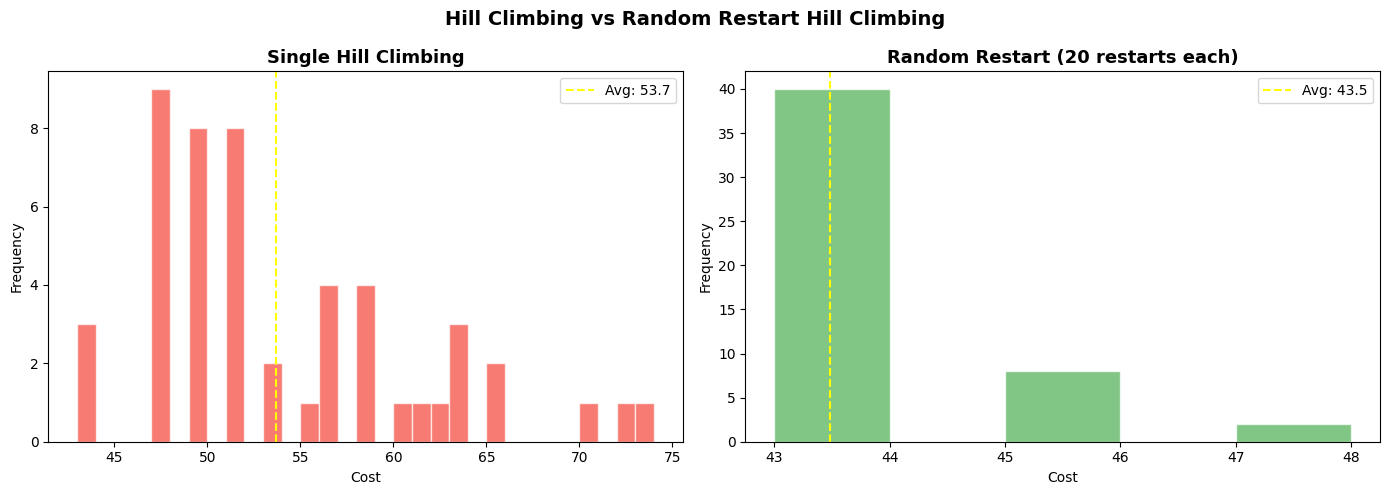

In [19]:
# Step 12: Compare approaches over many runs

single_costs = []
restart_costs = []

s2 = Space(height=10, width=20, num_hospitals=3)
random.seed(42)
for i in range(15):
    s2.add_house(random.randrange(s2.height), random.randrange(s2.width))

# Run 50 single hill climbs
for i in range(50):
    result = s2.hill_climb()
    single_costs.append(s2.get_cost(result))

# Run 50 random-restart hill climbs (each with 20 restarts)
for i in range(50):
    result = s2.random_restart(maximum=20)
    restart_costs.append(s2.get_cost(result))

print("COMPARISON: Single Hill Climb vs Random Restart")
print("=" * 55)
print(f"{'Metric':<25} {'Single HC':>12} {'Random Restart':>15}")
print("-" * 55)
print(f"{'Average cost':<25} {sum(single_costs)/len(single_costs):>12.1f} {sum(restart_costs)/len(restart_costs):>15.1f}")
print(f"{'Best cost':<25} {min(single_costs):>12} {min(restart_costs):>15}")
print(f"{'Worst cost':<25} {max(single_costs):>12} {max(restart_costs):>15}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(single_costs, bins=range(min(single_costs), max(single_costs)+2),
             color='#F44336', alpha=0.7, edgecolor='white')
axes[0].set_title('Single Hill Climbing', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cost')
axes[0].set_ylabel('Frequency')
axes[0].axvline(sum(single_costs)/len(single_costs), color='yellow',
                linestyle='--', label=f'Avg: {sum(single_costs)/len(single_costs):.1f}')
axes[0].legend()

axes[1].hist(restart_costs, bins=range(min(restart_costs), max(restart_costs)+2),
             color='#4CAF50', alpha=0.7, edgecolor='white')
axes[1].set_title('Random Restart (20 restarts each)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cost')
axes[1].set_ylabel('Frequency')
axes[1].axvline(sum(restart_costs)/len(restart_costs), color='yellow',
                linestyle='--', label=f'Avg: {sum(restart_costs)/len(restart_costs):.1f}')
axes[1].legend()

plt.suptitle('Hill Climbing vs Random Restart Hill Climbing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Summary: Key Concepts

### What We Learned

| Concept | Description |
|---------|-------------|
| **Optimization** | Choosing the best option from a set of options |
| **Local Search** | Search by maintaining a single state, moving to neighbors |
| **State** | A configuration (e.g., positions of all hospitals) |
| **Neighbor** | A state reachable by a small change (move one hospital by one cell) |
| **Cost Function** | What we minimize (sum of distances from houses to nearest hospital) |
| **Hill Climbing** | Always move to the best neighbor; stop when no improvement |
| **Local Minimum** | A state better than all neighbors, but not globally optimal |
| **Random Restart** | Run hill climbing many times, keep the best result |

### Hill Climbing Pseudocode

```
function HILL-CLIMB(problem):
    current = initial state of problem
    repeat:
        neighbor = best valued neighbor of current
        if neighbor not better than current:
            return current
        current = neighbor
```

### Hill Climbing Variants

| Variant | Description |
|---------|-------------|
| **Steepest-ascent** | Pick the single best neighbor (what we implemented) |
| **Stochastic** | Pick randomly among better neighbors |
| **First-choice** | Pick the first neighbor that is better |
| **Random Restart** | Run hill climbing multiple times |
| **Simulated Annealing** | Sometimes accept worse neighbors (covered in lecture) |